# Exercice 1.2 — Visualisations univariées et bivariées sur Ames Housing

Dans ce notebook, chaque graphique est interprété à partir de trois hypothèses directrices :

- **la qualité du bien** influence le prix ;
- **la surface habitable** influence le prix ;
- **la localisation** influence le prix.

Je privilégie donc les variables `Overall Qual`, `Gr Liv Area`, `Neighborhood` et `SalePrice`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('/mnt/data/AmesHousing.csv')

vars_keep = ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Overall Qual', 'Year Built', 'Neighborhood', 'House Style', 'Sale Condition']
df_subset = df[vars_keep].copy()
df_subset.head()

,SalePrice,Gr Liv Area,Lot Area,Overall Qual,Year Built,Neighborhood,House Style,Sale Condition
0,159000,1218,9605,7,2007,SawyerW,1Story,Normal
1,271900,2196,14684,7,1990,SawyerW,1Story,Normal
2,137500,1344,14375,6,1958,Timber,SLvl,Abnorml
3,248500,1456,6472,9,2008,NridgHt,1Story,Normal
4,167000,1374,9734,7,2004,Gilbert,SLvl,Normal


## 1. Visualisations univariées : variables continues

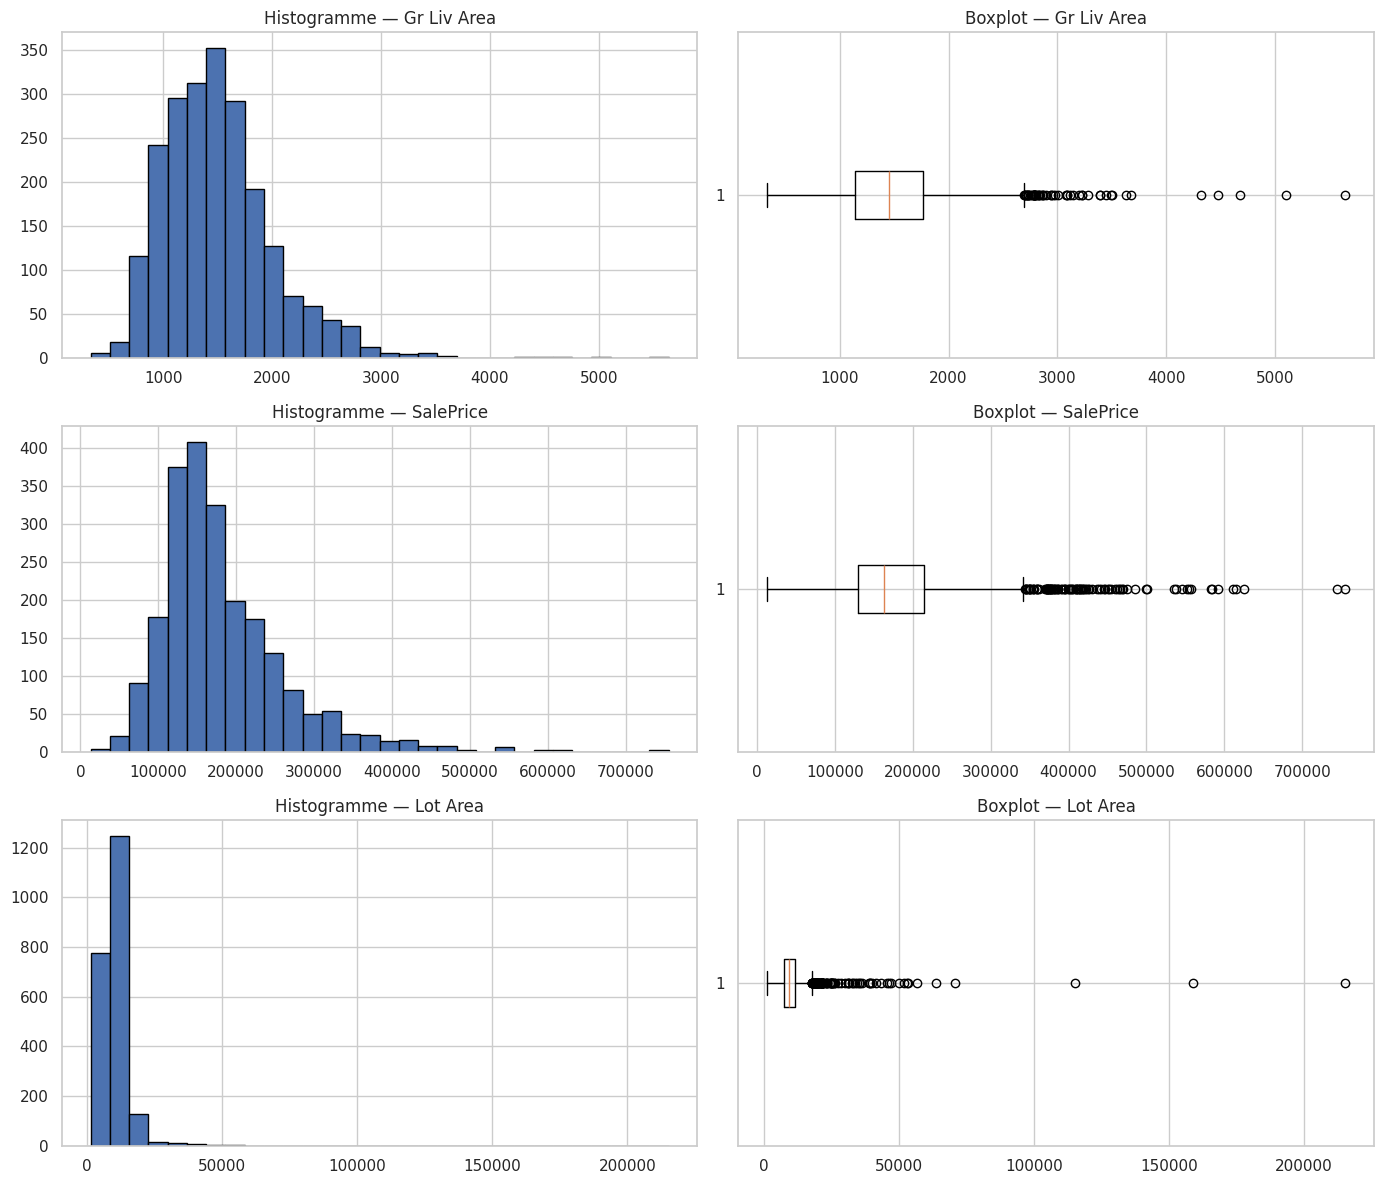

In [2]:
continuous_vars = ['Gr Liv Area', 'SalePrice', 'Lot Area']
fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(14, 12))

for i, var in enumerate(continuous_vars):
    s = df[var].dropna() if 'df' in globals() else df_subset[var].dropna()
    axes[i,0].hist(s, bins=30, edgecolor='black')
    axes[i,0].set_title(f'Histogramme — {var}')
    axes[i,1].boxplot(s, vert=False)
    axes[i,1].set_title(f'Boxplot — {var}')

plt.tight_layout()
plt.show()

### Réponse — Interprétation des distributions

- **`Gr Liv Area`** : la distribution est étalée à droite. Cela confirme l'idée qu'il existe quelques maisons très grandes, mais qu'elles restent minoritaires.
- **`SalePrice`** : la distribution est également étalée à droite. Cela soutient l'hypothèse d'un marché où quelques biens haut de gamme tirent les prix vers le haut.
- **`Lot Area`** : la distribution est encore plus asymétrique. Cette variable est utile, mais elle semble moins directement reliée au prix que la surface habitable.

Je préfère commenter `Gr Liv Area` plutôt que `Lot Area` quand je parle de taille du logement, car la surface habitable décrit mieux le confort intérieur. Le terrain peut être grand sans que la maison soit particulièrement valorisée.

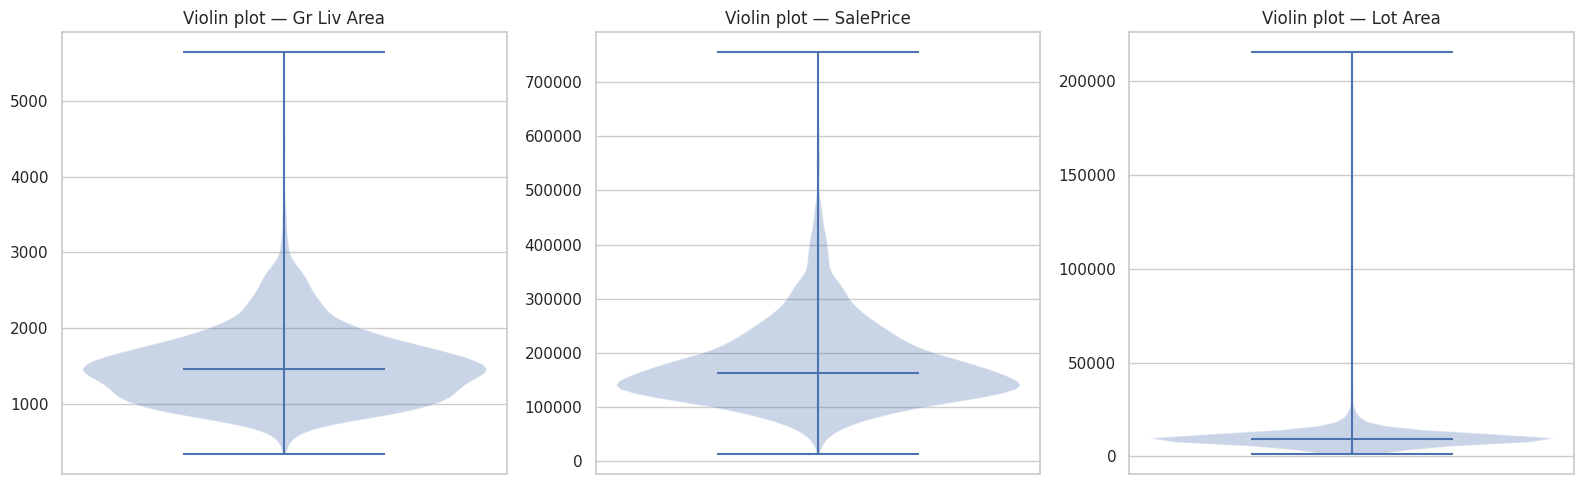

In [3]:
variables_continues = ['Gr Liv Area', 'SalePrice', 'Lot Area']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, var in enumerate(variables_continues):
    axes[i].violinplot(df_subset[var].dropna(), showmeans=False, showmedians=True)
    axes[i].set_title(f'Violin plot — {var}')
    axes[i].set_xticks([])
plt.tight_layout()
plt.show()

### Réponse — Pourquoi utiliser un violin plot ?

Le violin plot complète le boxplot en montrant la **densité** de la distribution. Il permet donc de voir où se concentrent les observations, pas seulement les quartiles et les valeurs extrêmes.

Je l'utilise ici pour visualiser plus finement la forme des distributions, notamment pour `Lot Area`, qui présente une masse centrale dense et une longue queue de valeurs extrêmes.

## 2. Variables discrètes et qualitatives

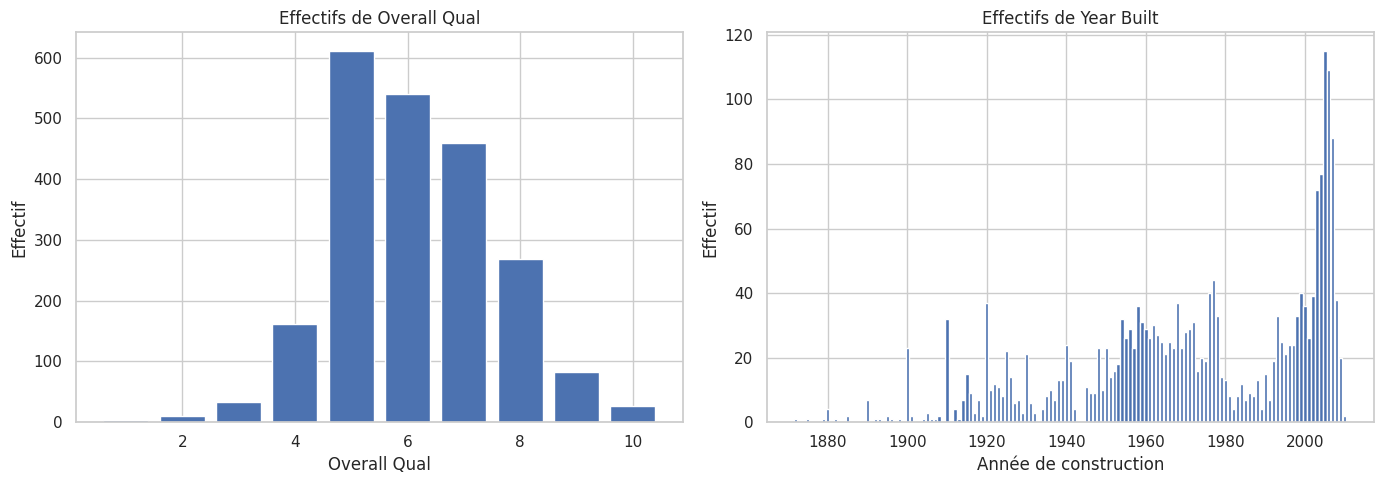

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qual_counts = df_subset['Overall Qual'].value_counts().sort_index()
axes[0].bar(qual_counts.index, qual_counts.values)
axes[0].set_title('Effectifs de Overall Qual')
axes[0].set_xlabel('Overall Qual')
axes[0].set_ylabel('Effectif')

year_counts = df_subset['Year Built'].value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values)
axes[1].set_title('Effectifs de Year Built')
axes[1].set_xlabel('Année de construction')
axes[1].set_ylabel('Effectif')

plt.tight_layout()
plt.show()

### Réponse — Pourquoi un diagramme en barres ?

Pour `Overall Qual` et `Year Built`, le diagramme en barres est plus adapté qu'un histogramme, car on travaille ici avec des **valeurs discrètes** ou assimilées à des catégories distinctes. Cela évite de créer des classes artificielles.

`Overall Qual` est particulièrement intéressant pour l'oral, car il correspond directement à l'hypothèse sur la **qualité du bien**.

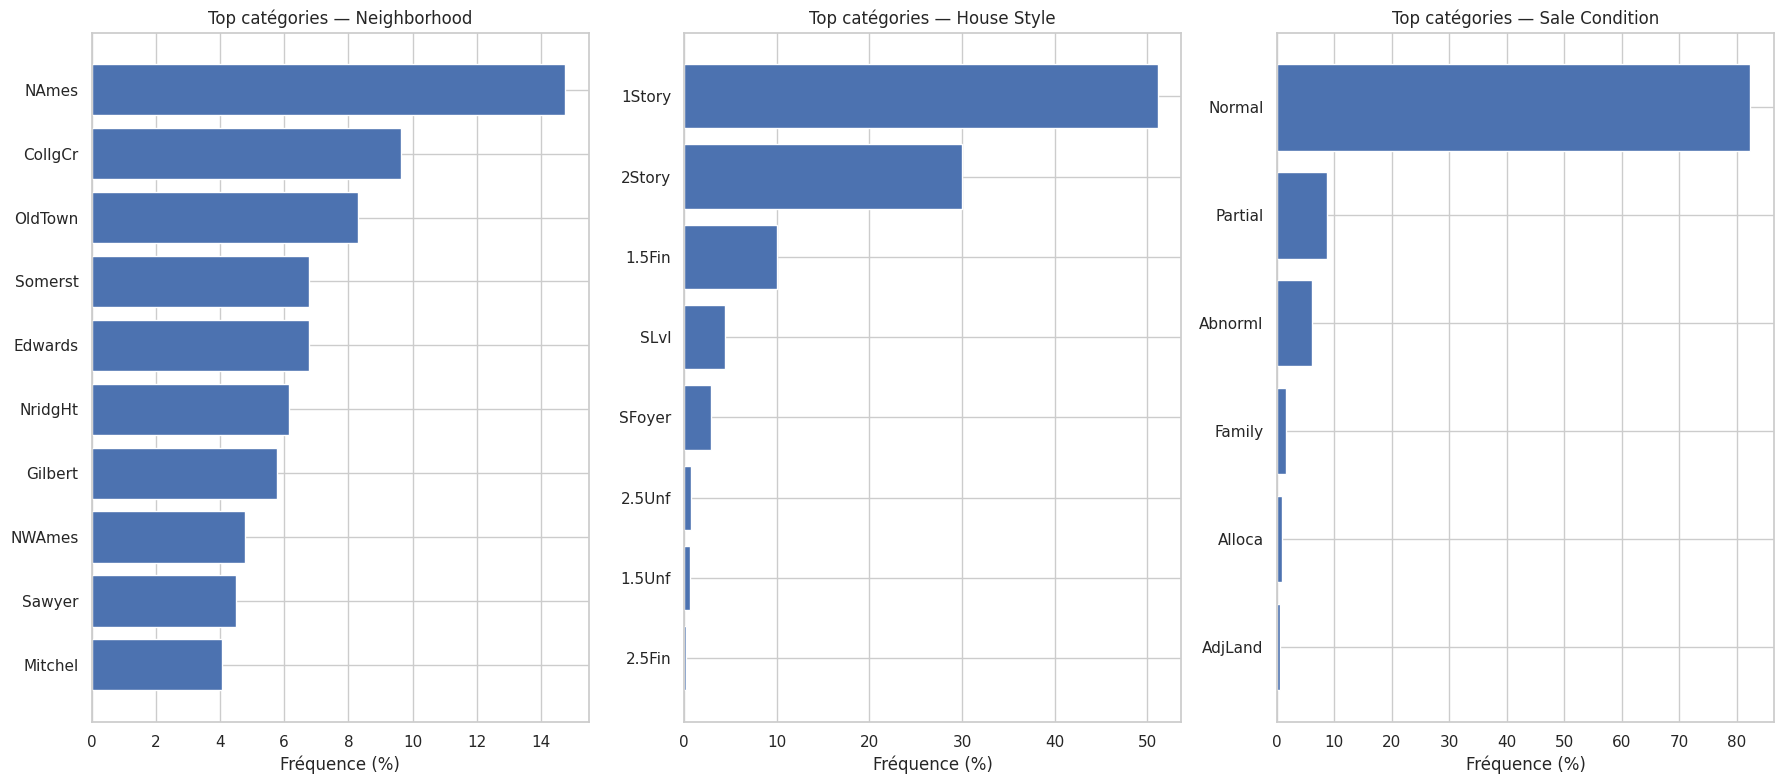

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
qual_vars = ['Neighborhood', 'House Style', 'Sale Condition']

for ax, var in zip(axes, qual_vars):
    freq = df_subset[var].value_counts(normalize=True).sort_values(ascending=True).tail(10) * 100
    ax.barh(freq.index, freq.values)
    ax.set_title(f'Top catégories — {var}')
    ax.set_xlabel('Fréquence (%)')

plt.tight_layout()
plt.show()

### Réponse — Variables qualitatives

`Neighborhood` est la variable qualitative la plus importante pour mon oral, car elle représente directement la **localisation**. Je la privilégie donc par rapport à `House Style` ou `Sale Condition`, qui restent utiles mais plus secondaires pour expliquer la valeur du bien.

Le fait qu'un quartier comme `NAmes` soit très représenté montre aussi qu'il existe un déséquilibre d'effectifs entre zones. Il faudra donc interpréter les comparaisons de quartiers avec prudence.

## 3. Analyse bivariée : surface habitable et prix

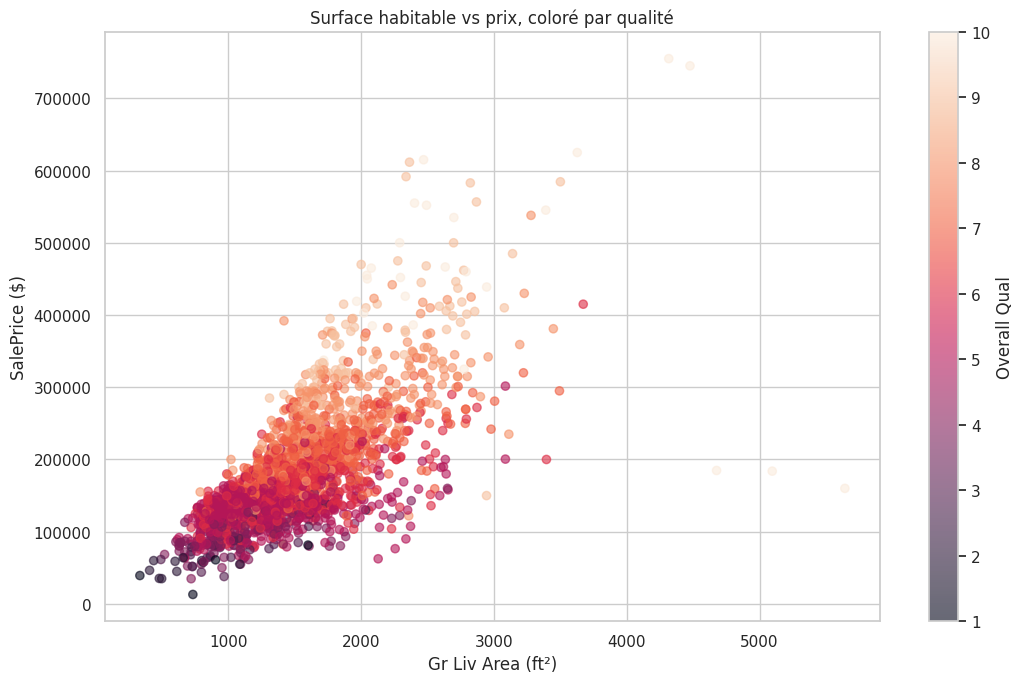

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    df_subset['Gr Liv Area'],
    df_subset['SalePrice'],
    c=df_subset['Overall Qual'],
    alpha=0.6
)
ax.set_title('Surface habitable vs prix, coloré par qualité')
ax.set_xlabel('Gr Liv Area (ft²)')
ax.set_ylabel('SalePrice ($)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Overall Qual')
plt.tight_layout()
plt.show()

### Réponse — `Gr Liv Area` vs `SalePrice`

Le nuage de points montre une relation **croissante** entre surface habitable et prix : plus la maison est grande, plus son prix tend à augmenter. En colorant par `Overall Qual`, on voit aussi que la qualité module fortement cette relation : à surface comparable, les maisons de meilleure qualité sont souvent plus chères.

J'utilise ici `Gr Liv Area` comme variable explicative principale plutôt qu'une autre mesure de taille, car elle correspond le mieux à l'espace habitable réellement valorisé par les acheteurs.

## 4. Analyse bivariée : qualité et prix

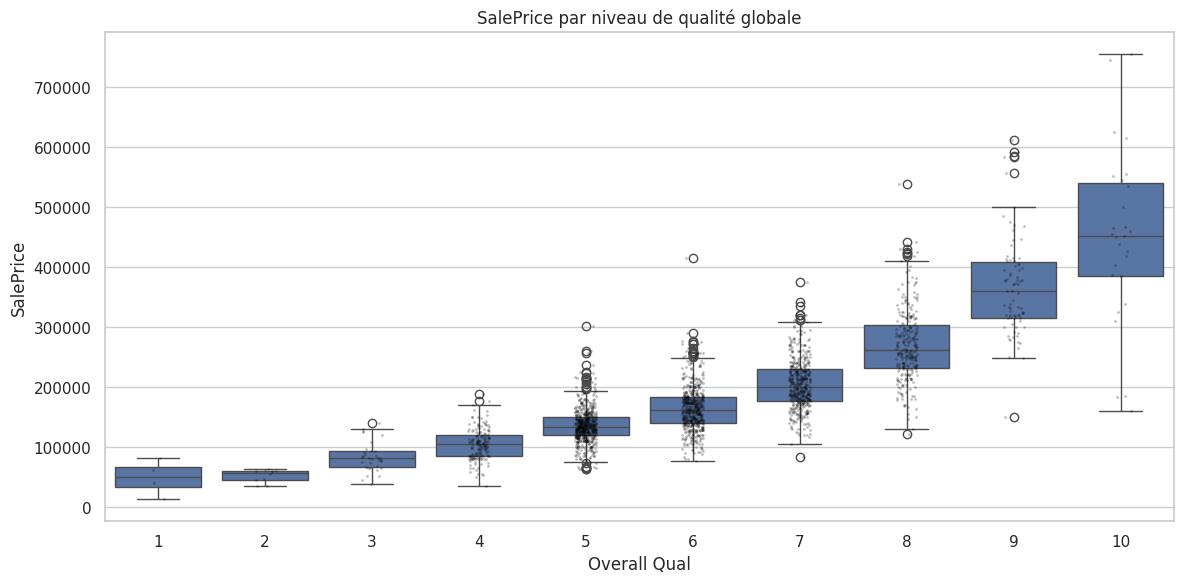

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='Overall Qual', y='SalePrice', data=df_subset, ax=ax)
sns.stripplot(x='Overall Qual', y='SalePrice', data=df_subset, ax=ax, color='black', alpha=0.25, size=2)
ax.set_title('SalePrice par niveau de qualité globale')
plt.tight_layout()
plt.show()

### Réponse — `Overall Qual` vs `SalePrice`

Ce graphique confirme très bien l'hypothèse principale : **plus la qualité du bien augmente, plus le prix médian augmente**. La relation est monotone croissante, avec une accélération visible sur les niveaux de qualité élevés.

Je choisis `Overall Qual` et non `Overall Cond` parce que la qualité de construction et de finition explique davantage la valeur marchande qu'un simple état d'entretien.

## 5. Analyse bivariée : localisation et prix

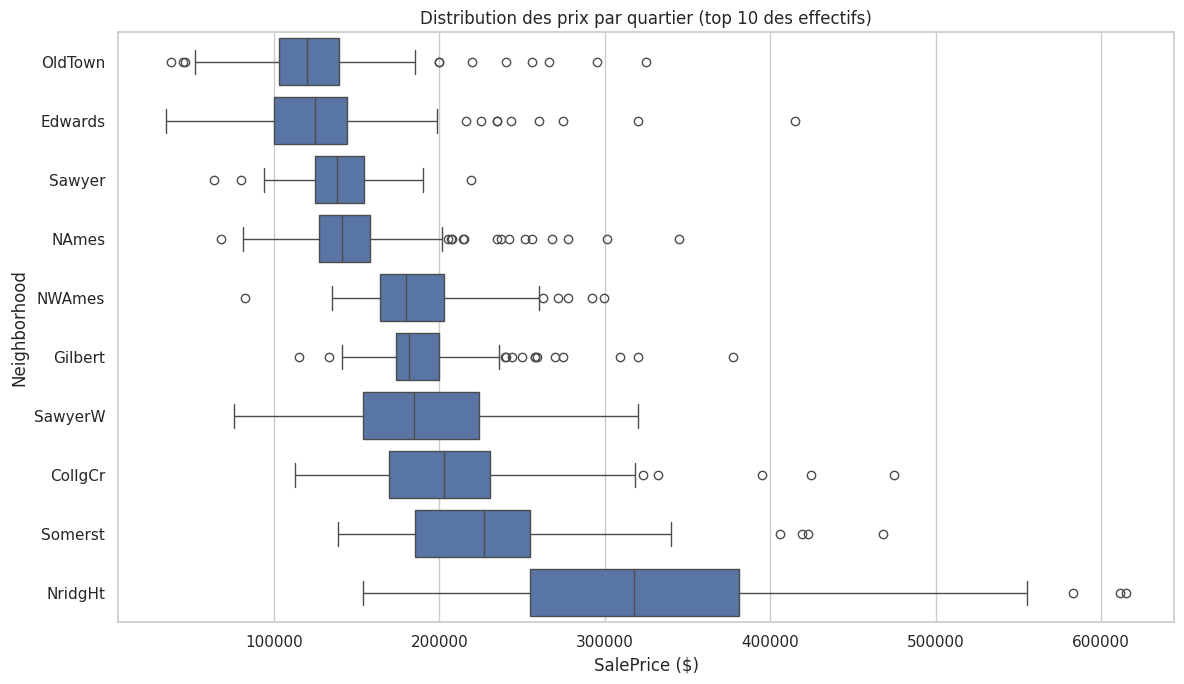

In [8]:
top10 = df['Neighborhood'].value_counts().head(10).index
df_top = df[df['Neighborhood'].isin(top10)].copy()

order = df_top.groupby('Neighborhood')['SalePrice'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=df_top, x='SalePrice', y='Neighborhood', order=order, ax=ax)
ax.set_title('Distribution des prix par quartier (top 10 des effectifs)')
ax.set_xlabel('SalePrice ($)')
ax.set_ylabel('Neighborhood')
plt.tight_layout()
plt.show()

### Réponse — `Neighborhood` vs `SalePrice`

Ce graphique montre que la **localisation** joue un rôle important : les distributions de prix diffèrent clairement selon les quartiers. Même si les quartiers n'ont pas tous le même nombre d'observations, on observe des niveaux de prix médians très différents.

J'ai choisi un boxplot par quartier plutôt qu'un simple graphique de moyennes, car le boxplot montre aussi la **dispersion**, les **quartiles** et les **valeurs atypiques**. C'est plus rigoureux pour l'oral.

## 6. Matrice de corrélation

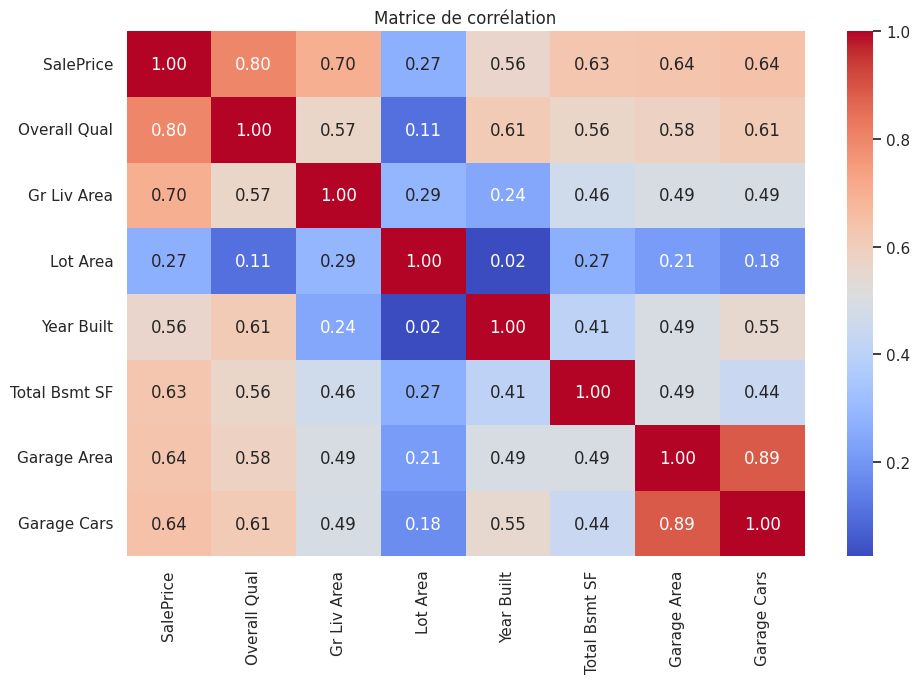

SalePrice        1.000000
Overall Qual     0.799928
Gr Liv Area      0.699675
Garage Cars      0.644091
Garage Area      0.637427
Total Bsmt SF    0.629263
Year Built       0.559975
Lot Area         0.269321
Name: SalePrice, dtype: float64

In [9]:
vars_corr = ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Lot Area', 'Year Built', 'Total Bsmt SF', 'Garage Area', 'Garage Cars']
corr = df[vars_corr].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

corr['SalePrice'].sort_values(ascending=False)

### Réponse — Corrélations

Les corrélations confirment que `Overall Qual` et `Gr Liv Area` sont parmi les variables les plus liées à `SalePrice`. Cela renforce le choix de mes hypothèses de départ.

Je conserve `Lot Area` comme variable de comparaison, mais elle semble moins explicative que la surface habitable. Cela montre bien qu'en immobilier, la taille intérieure et la qualité du bien expliquent souvent mieux le prix que la taille du terrain seule.

## 7. Conclusion visuelle

### Réponse — Synthèse

Les graphiques soutiennent globalement trois idées :

1. **Qualité du bien** : `Overall Qual` est une variable centrale pour expliquer le prix.
2. **Surface habitable** : `Gr Liv Area` a une relation positive claire avec `SalePrice`.
3. **Localisation** : `Neighborhood` différencie fortement les niveaux de prix.

Ces trois axes sont donc cohérents à la fois pour l'analyse statistique et pour la présentation orale.